# Notebook 2: Variables aleatorias

## Diplomado - Módulo II: Técnicas Estadísticas

Este notebook cubre variables aleatorias discretas y continuas: su definición, función de probabilidad o densidad, esperanza y varianza, visualización y simulación. También se desarrollan la transformada inversa, la función generadora de momentos (FGM), la función característica (FC), la Ley de los Grandes Números (LGN) y el Teorema Central del Límite (TCL).

Cada tema incluye primero la explicación conceptual y después el código. Los cálculos con `print` y las gráficas se colocan en celdas de código separadas.

In [1]:
# Bibliotecas utilizadas en todo el notebook
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 5)
rng = np.random.default_rng(2024)

---
# A. Variables aleatorias discretas

Una **variable aleatoria discreta** $X$ toma valores en un conjunto finito o infinito numerable. Se describe mediante su **función de probabilidad** (o función de masa de probabilidad) $p(x) = P(X = x)$, que satisface $p(x) \ge 0$ y $\sum_x p(x) = 1$. Su **función de distribución acumulada** es $F(x) = P(X \le x) = \sum_{k \le x} p(k)$.

Para cada distribución de esta sección se presenta: definición, función de probabilidad, propiedades, esperanza, varianza, una gráfica de la función de masa de probablidad y un ejercicio adicional aplicado.

## A.1 Uniforme discreta

Modela un experimento con $n$ resultados igualmente probables, por ejemplo $X \in \{1, 2, \dots, n\}$.

$$p(x) = \frac{1}{n}, \quad x = 1, \dots, n \qquad\qquad E[X] = \frac{n+1}{2} \qquad\qquad \text{Var}(X) = \frac{n^2 - 1}{12}$$

Ejemplo: el resultado de lanzar un dado justo de 6 caras, $X \in \{1, \dots, 6\}$.

In [ ]:
n = 6
dist_uniforme = stats.randint(1, n + 1)

x_vals = np.arange(1, n + 1)
print("Valores posibles de X:", x_vals)
print("Funcion de probabilidad p(x):", np.round(dist_uniforme.pmf(x_vals), 4))
print("Esperanza teorica E[X] =", dist_uniforme.mean(), " (formula: (n+1)/2 =", (n + 1) / 2, ")")
print("Varianza teorica Var(X) =", round(dist_uniforme.var(), 4), " (formula: (n^2-1)/12 =", round((n**2 - 1) / 12, 4), ")")

Valores posibles de X: [1 2 3 4 5 6]
Funcion de probabilidad p(x): [0.1667 0.1667 0.1667 0.1667 0.1667 0.1667]
Esperanza teorica E[X] = 3.5  (formula: (n+1)/2 = 3.5 )
Varianza teorica Var(X) = 2.9167  (formula: (n^2-1)/12 = 2.9167 )


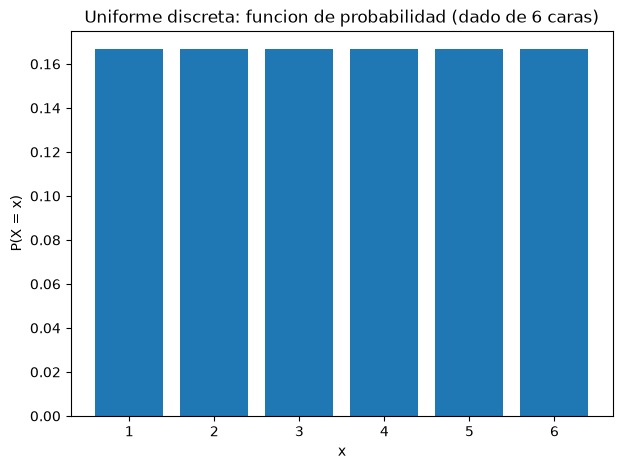

In [3]:
plt.figure()
plt.bar(x_vals, dist_uniforme.pmf(x_vals), color="tab:blue")
plt.xlabel("x")
plt.ylabel("P(X = x)")
plt.title("Uniforme discreta: funcion de probabilidad (dado de 6 caras)")
plt.show()

**Ejercicio adicional:** en una rifa con boletos numerados del 1 al 50, ¿cuál es la probabilidad de que el boleto ganador sea mayor a 40?

In [4]:
dist_rifa = stats.randint(1, 51)
p_mayor_40 = 1 - dist_rifa.cdf(40)  # P(X > 40) = 1 - P(X <= 40)
print("P(X > 40) =", round(p_mayor_40, 4))

P(X > 40) = 0.2


## A.2 Bernoulli

Modela un experimento con dos resultados posibles: éxito ($X=1$) con probabilidad $p$ o fracaso ($X=0$) con probabilidad $1-p$.

$$p(x) = p^x (1-p)^{1-x}, \quad x \in \{0, 1\} \qquad\qquad E[X] = p \qquad\qquad \text{Var}(X) = p(1-p)$$

Ejemplo: un artículo producido en una línea de manufactura es defectuoso ($X=1$) con probabilidad $p = 0.05$.

In [5]:
p = 0.05
dist_bernoulli = stats.bernoulli(p)

x_vals = np.array([0, 1])
print("Funcion de probabilidad p(x):", dist_bernoulli.pmf(x_vals))
print("Esperanza teorica E[X] =", dist_bernoulli.mean(), " (formula: p =", p, ")")
print("Varianza teorica Var(X) =", round(dist_bernoulli.var(), 4), " (formula: p(1-p) =", round(p * (1 - p), 4), ")")

Funcion de probabilidad p(x): [0.95 0.05]
Esperanza teorica E[X] = 0.05  (formula: p = 0.05 )
Varianza teorica Var(X) = 0.0475  (formula: p(1-p) = 0.0475 )


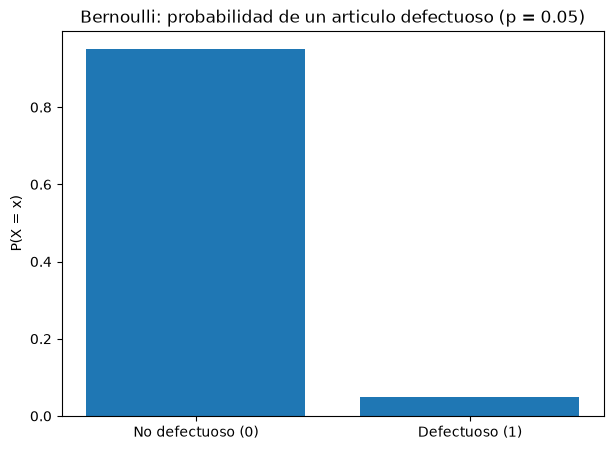

In [6]:
plt.figure()
plt.bar(x_vals, dist_bernoulli.pmf(x_vals), color="tab:blue", tick_label=["No defectuoso (0)", "Defectuoso (1)"])
plt.ylabel("P(X = x)")
plt.title("Bernoulli: probabilidad de un articulo defectuoso (p = 0.05)")
plt.show()

**Ejercicio adicional:** si se revisa un solo artículo, ¿cuál es la probabilidad de que **no** sea defectuoso?

In [7]:
p_no_defectuoso = dist_bernoulli.pmf(0)
print("P(X = 0) =", p_no_defectuoso)

P(X = 0) = 0.95


## A.3 Binomial

Cuenta el número de éxitos en $n$ ensayos Bernoulli independientes con probabilidad de éxito $p$.

$$p(x) = \binom{n}{x} p^x (1-p)^{n-x}, \quad x = 0, 1, \dots, n \qquad\qquad E[X] = np \qquad\qquad \text{Var}(X) = np(1-p)$$

Ejemplo: en un lote de $n = 20$ artículos, cada uno defectuoso de forma independiente con probabilidad $p = 0.05$, $X$ es el número de artículos defectuosos.

In [8]:
n, p = 20, 0.05
dist_binomial = stats.binom(n, p)

x_vals = np.arange(0, n + 1)
print("Esperanza teorica E[X] =", dist_binomial.mean(), " (formula: n*p =", n * p, ")")
print("Varianza teorica Var(X) =", round(dist_binomial.var(), 4), " (formula: n*p*(1-p) =", round(n * p * (1 - p), 4), ")")
print("P(X = 0) (ningun defectuoso) =", round(dist_binomial.pmf(0), 4))
print("P(X <= 2) (a lo mas 2 defectuosos) =", round(dist_binomial.cdf(2), 4))

Esperanza teorica E[X] = 1.0  (formula: n*p = 1.0 )
Varianza teorica Var(X) = 0.95  (formula: n*p*(1-p) = 0.95 )
P(X = 0) (ningun defectuoso) = 0.3585
P(X <= 2) (a lo mas 2 defectuosos) = 0.9245


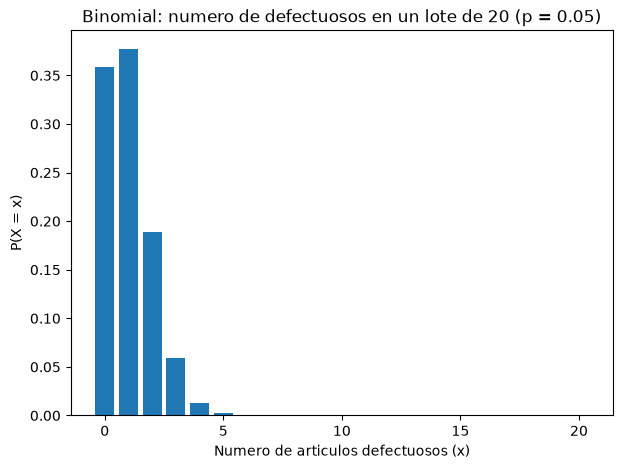

In [9]:
plt.figure()
plt.bar(x_vals, dist_binomial.pmf(x_vals), color="tab:blue")
plt.xlabel("Numero de articulos defectuosos (x)")
plt.ylabel("P(X = x)")
plt.title(f"Binomial: numero de defectuosos en un lote de {n} (p = {p})")
plt.show()

**Ejercicio adicional:** ¿cuál es la probabilidad de que en el lote haya **más de 3** artículos defectuosos?

In [10]:
p_mas_de_3 = 1 - dist_binomial.cdf(3)
print("P(X > 3) =", round(p_mas_de_3, 4))

P(X > 3) = 0.0159


## A.4 Geométrica

Cuenta el número de ensayos Bernoulli independientes (con probabilidad de éxito $p$) necesarios **hasta obtener el primer éxito**, incluyendo el ensayo exitoso.

$$p(x) = (1-p)^{x-1} p, \quad x = 1, 2, 3, \dots \qquad\qquad E[X] = \frac{1}{p} \qquad\qquad \text{Var}(X) = \frac{1-p}{p^2}$$

Ejemplo: un vendedor telefónico logra una venta en cada llamada con probabilidad $p = 0.2$. $X$ es el número de llamadas hasta lograr la primera venta.

In [11]:
p = 0.2
dist_geometrica = stats.geom(p)

x_vals = np.arange(1, 21)
print("Esperanza teorica E[X] =", dist_geometrica.mean(), " (formula: 1/p =", 1 / p, ")")
print("Varianza teorica Var(X) =", round(dist_geometrica.var(), 4), " (formula: (1-p)/p^2 =", round((1 - p) / p**2, 4), ")")
print("P(X = 1) (venta en la primera llamada) =", round(dist_geometrica.pmf(1), 4))

Esperanza teorica E[X] = 5.0  (formula: 1/p = 5.0 )
Varianza teorica Var(X) = 20.0  (formula: (1-p)/p^2 = 20.0 )
P(X = 1) (venta en la primera llamada) = 0.2


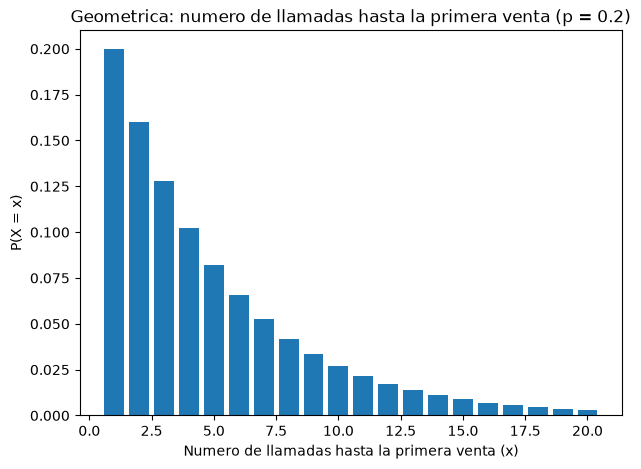

In [12]:
plt.figure()
plt.bar(x_vals, dist_geometrica.pmf(x_vals), color="tab:blue")
plt.xlabel("Numero de llamadas hasta la primera venta (x)")
plt.ylabel("P(X = x)")
plt.title("Geometrica: numero de llamadas hasta la primera venta (p = 0.2)")
plt.show()

**Ejercicio adicional:** ¿cuál es la probabilidad de que se necesiten **más de 5 llamadas** para lograr la primera venta?

In [13]:
p_mas_de_5 = 1 - dist_geometrica.cdf(5)
print("P(X > 5) =", round(p_mas_de_5, 4))

P(X > 5) = 0.3277


## A.5 Poisson

Modela el número de eventos que ocurren en un intervalo fijo de tiempo o espacio, cuando los eventos ocurren de forma independiente a una tasa promedio constante $\lambda$.

$$p(x) = \frac{e^{-\lambda} \lambda^x}{x!}, \quad x = 0, 1, 2, \dots \qquad\qquad E[X] = \lambda \qquad\qquad \text{Var}(X) = \lambda$$

Ejemplo: un centro de llamadas recibe en promedio $\lambda = 4$ llamadas por minuto. $X$ es el número de llamadas recibidas en un minuto.

In [14]:
lam = 4
dist_poisson = stats.poisson(lam)

x_vals = np.arange(0, 16)
print("Esperanza teorica E[X] =", dist_poisson.mean(), " (formula: lambda =", lam, ")")
print("Varianza teorica Var(X) =", dist_poisson.var(), " (formula: lambda =", lam, ")")
print("P(X = 0) (ninguna llamada) =", round(dist_poisson.pmf(0), 4))

Esperanza teorica E[X] = 4.0  (formula: lambda = 4 )
Varianza teorica Var(X) = 4.0  (formula: lambda = 4 )
P(X = 0) (ninguna llamada) = 0.0183


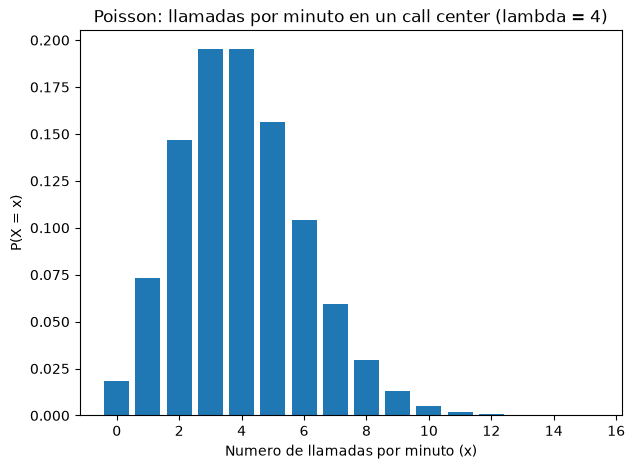

In [15]:
plt.figure()
plt.bar(x_vals, dist_poisson.pmf(x_vals), color="tab:blue")
plt.xlabel("Numero de llamadas por minuto (x)")
plt.ylabel("P(X = x)")
plt.title("Poisson: llamadas por minuto en un call center (lambda = 4)")
plt.show()

**Ejercicio adicional:** ¿cuál es la probabilidad de recibir **más de 6 llamadas** en un minuto?

In [16]:
p_mas_de_6 = 1 - dist_poisson.cdf(6)
print("P(X > 6) =", round(p_mas_de_6, 4))

P(X > 6) = 0.1107


## A.6 Binomial negativa

Generaliza a la geométrica: cuenta el número de ensayos necesarios hasta obtener el **r-ésimo éxito** en ensayos Bernoulli independientes con probabilidad $p$.

$$p(x) = \binom{x-1}{r-1} p^r (1-p)^{x-r}, \quad x = r, r+1, \dots \qquad\qquad E[X] = \frac{r}{p} \qquad\qquad \text{Var}(X) = \frac{r(1-p)}{p^2}$$

Ejemplo: el mismo vendedor (probabilidad de venta $p = 0.2$ por llamada) quiere lograr $r = 3$ ventas. $X$ es el número de llamadas necesarias. `scipy.stats.nbinom` cuenta el número de **fracasos** antes del r-ésimo éxito, por lo que se usa $X = \text{fracasos} + r$.

In [ ]:
r, p = 3, 0.2
dist_nbinom_fallos = stats.nbinom(r, p)  # cuenta fallos antes del r-esimo exito

x_vals = np.arange(r, r + 40)  # numero total de llamadas (fallos + r exitos)
pmf_x = dist_nbinom_fallos.pmf(x_vals - r)

esperanza_teorica = r / p
varianza_teorica = r * (1 - p) / p**2

print("Esperanza teorica E[X] = r/p =", esperanza_teorica)
print("Varianza teorica Var(X) = r*(1-p)/p^2 =", round(varianza_teorica, 4))
print("P(X = 15) (exactamente 15 llamadas para lograr 3 ventas) =", round(dist_nbinom_fallos.pmf(15 - r), 4))

Esperanza teorica E[X] = r/p = 15.0
Varianza teorica Var(X) = r*(1-p)/p^2 = 60.0
P(X = 15) (exactamente 15 llamadas para lograr 3 ventas) = 0.05


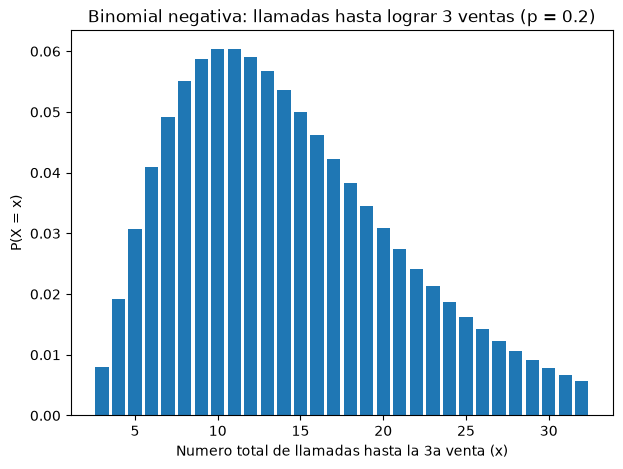

In [47]:
plt.figure()
plt.bar(x_vals, pmf_x, color="tab:blue")
plt.xlabel("Numero total de llamadas hasta la 3a venta (x)")
plt.ylabel("P(X = x)")
plt.title("Binomial negativa: llamadas hasta lograr 3 ventas (p = 0.2)")
plt.show()

**Ejercicio adicional:** ¿cuál es la probabilidad de necesitar **a lo más 10 llamadas** para lograr las 3 ventas?

In [19]:
p_a_lo_mas_10 = dist_nbinom_fallos.cdf(10 - r)
print("P(X <= 10) =", round(p_a_lo_mas_10, 4))

P(X <= 10) = 0.3222


## A.7 Hipergeométrica

Modela el número de éxitos al extraer una muestra de tamaño $n$ **sin reemplazo** de una población finita de tamaño $N$ que contiene $K$ elementos exitosos.

$$p(x) = \frac{\binom{K}{x} \binom{N-K}{n-x}}{\binom{N}{n}} \qquad\qquad E[X] = n\frac{K}{N} \qquad\qquad \text{Var}(X) = n\frac{K}{N}\frac{N-K}{N}\frac{N-n}{N-1}$$

Ejemplo: un lote tiene $N = 50$ artículos, de los cuales $K = 5$ son defectuosos. Se toma una muestra sin reemplazo de $n = 10$ artículos. $X$ es el número de artículos defectuosos en la muestra.

In [20]:
N, K, n = 50, 5, 10
dist_hipergeometrica = stats.hypergeom(N, K, n)

x_vals = np.arange(0, min(K, n) + 1)
esperanza_teorica = n * K / N
varianza_teorica = n * (K / N) * ((N - K) / N) * ((N - n) / (N - 1))

print("Esperanza teorica E[X] =", round(esperanza_teorica, 4))
print("Varianza teorica Var(X) =", round(varianza_teorica, 4))
print("P(X = 0) (ningun defectuoso en la muestra) =", round(dist_hipergeometrica.pmf(0), 4))

Esperanza teorica E[X] = 1.0
Varianza teorica Var(X) = 0.7347
P(X = 0) (ningun defectuoso en la muestra) = 0.3106


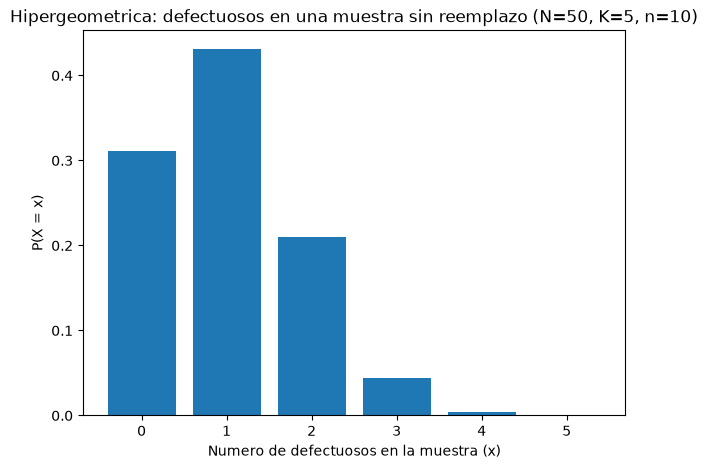

In [21]:
plt.figure()
plt.bar(x_vals, dist_hipergeometrica.pmf(x_vals), color="tab:blue")
plt.xlabel("Numero de defectuosos en la muestra (x)")
plt.ylabel("P(X = x)")
plt.title("Hipergeometrica: defectuosos en una muestra sin reemplazo (N=50, K=5, n=10)")
plt.show()

**Ejercicio adicional:** ¿cuál es la probabilidad de encontrar **al menos 2 defectuosos** en la muestra?

In [22]:
p_al_menos_2 = 1 - dist_hipergeometrica.cdf(1)
print("P(X >= 2) =", round(p_al_menos_2, 4))

P(X >= 2) = 0.2581


---
# B. Variables aleatorias continuas

Una **variable aleatoria continua** $X$ se describe mediante su **función de densidad de probabilidad** $f(x) \ge 0$, con $\int_{-\infty}^{\infty} f(x)\,dx = 1$, de modo que $P(a \le X \le b) = \int_a^b f(x)\,dx$. Su **función de distribución acumulada** es $F(x) = P(X \le x) = \int_{-\infty}^{x} f(t)\,dt$. La esperanza y varianza se definen mediante integrales: $E[X] = \int x f(x)\,dx$ y $\text{Var}(X) = E[X^2] - (E[X])^2$.

Para cada distribución se presenta definición, densidad, distribución acumulada, esperanza, varianza, gráfica de pdf y cdf, y una simulación que compara el histograma empírico contra la densidad teórica.

## B.1 Uniforme continua

Todos los valores en el intervalo $[a, b]$ son igualmente probables.

$$f(x) = \frac{1}{b-a}, \; a \le x \le b \qquad F(x) = \frac{x-a}{b-a} \qquad\qquad E[X] = \frac{a+b}{2} \qquad\qquad \text{Var}(X) = \frac{(b-a)^2}{12}$$

Ejemplo: el tiempo de espera (en minutos) de un autobús que llega en cualquier instante entre 0 y 10 minutos de forma equiprobable, $X \sim \text{Uniforme}(0, 10)$.

In [23]:
a, b = 0, 10
dist_unif_cont = stats.uniform(loc=a, scale=b - a)

print("Esperanza teorica E[X] =", dist_unif_cont.mean(), " (formula: (a+b)/2 =", (a + b) / 2, ")")
print("Varianza teorica Var(X) =", round(dist_unif_cont.var(), 4), " (formula: (b-a)^2/12 =", round((b - a) ** 2 / 12, 4), ")")
print("P(X <= 3) =", round(dist_unif_cont.cdf(3), 4))

Esperanza teorica E[X] = 5.0  (formula: (a+b)/2 = 5.0 )
Varianza teorica Var(X) = 8.3333  (formula: (b-a)^2/12 = 8.3333 )
P(X <= 3) = 0.3


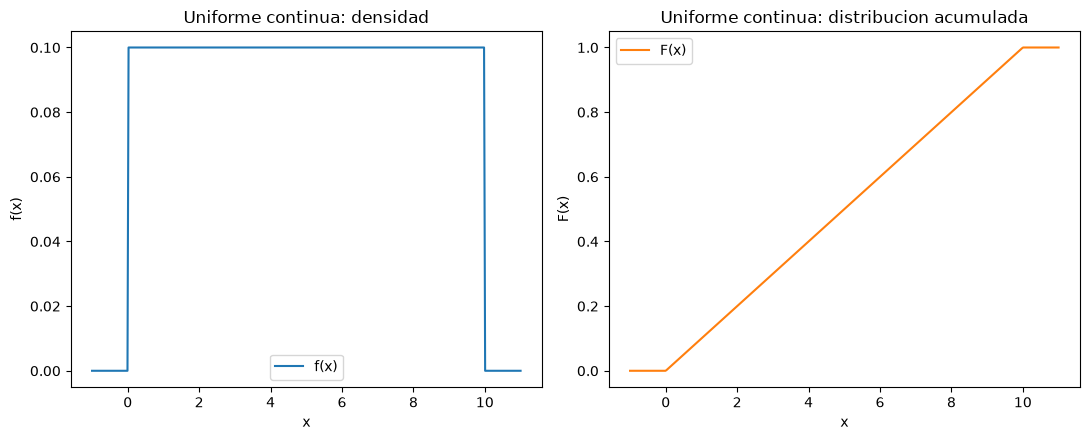

In [24]:
x_vals = np.linspace(-1, 11, 400)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(x_vals, dist_unif_cont.pdf(x_vals), label="f(x)")
axes[0].set_title("Uniforme continua: densidad")
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")
axes[0].legend()

axes[1].plot(x_vals, dist_unif_cont.cdf(x_vals), color="tab:orange", label="F(x)")
axes[1].set_title("Uniforme continua: distribucion acumulada")
axes[1].set_xlabel("x")
axes[1].set_ylabel("F(x)")
axes[1].legend()
plt.tight_layout()
plt.show()

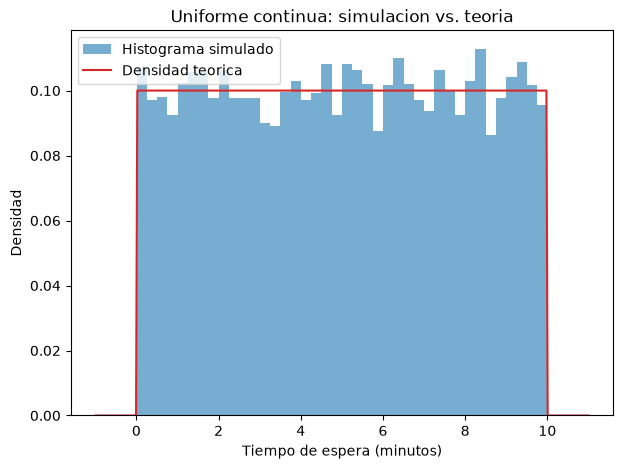

In [25]:
muestra = dist_unif_cont.rvs(size=10_000, random_state=rng)

plt.figure()
plt.hist(muestra, bins=40, density=True, alpha=0.6, color="tab:blue", label="Histograma simulado")
plt.plot(x_vals, dist_unif_cont.pdf(x_vals), color="tab:red", label="Densidad teorica")
plt.xlabel("Tiempo de espera (minutos)")
plt.ylabel("Densidad")
plt.title("Uniforme continua: simulacion vs. teoria")
plt.legend()
plt.show()

## B.2 Normal

Distribución en forma de campana, determinada por su media $\mu$ y desviación estándar $\sigma$.

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right) \qquad\qquad E[X] = \mu \qquad\qquad \text{Var}(X) = \sigma^2$$

No tiene forma cerrada para $F(x)$; se calcula numéricamente. Ejemplo: la estatura (en cm) de personas adultas, $X \sim N(170, 8^2)$, con error de medición aleatorio.

In [26]:
mu, sigma = 170, 8
dist_normal = stats.norm(loc=mu, scale=sigma)

print("Esperanza teorica E[X] =", dist_normal.mean(), " (formula: mu =", mu, ")")
print("Varianza teorica Var(X) =", dist_normal.var(), " (formula: sigma^2 =", sigma**2, ")")
print("P(X <= 180) =", round(dist_normal.cdf(180), 4))
print("P(160 <= X <= 180) =", round(dist_normal.cdf(180) - dist_normal.cdf(160), 4))

Esperanza teorica E[X] = 170.0  (formula: mu = 170 )
Varianza teorica Var(X) = 64.0  (formula: sigma^2 = 64 )
P(X <= 180) = 0.8944
P(160 <= X <= 180) = 0.7887


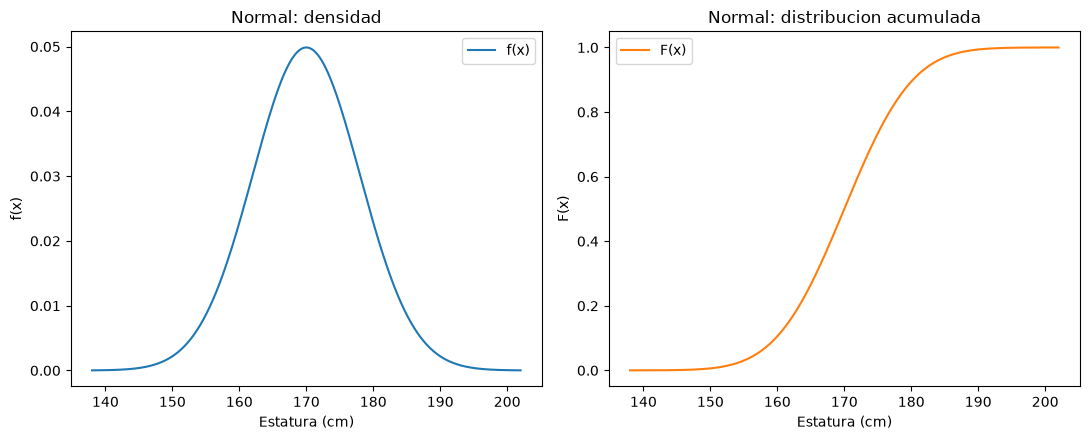

In [27]:
x_vals = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 400)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(x_vals, dist_normal.pdf(x_vals), label="f(x)")
axes[0].set_title("Normal: densidad")
axes[0].set_xlabel("Estatura (cm)")
axes[0].set_ylabel("f(x)")
axes[0].legend()

axes[1].plot(x_vals, dist_normal.cdf(x_vals), color="tab:orange", label="F(x)")
axes[1].set_title("Normal: distribucion acumulada")
axes[1].set_xlabel("Estatura (cm)")
axes[1].set_ylabel("F(x)")
axes[1].legend()
plt.tight_layout()
plt.show()

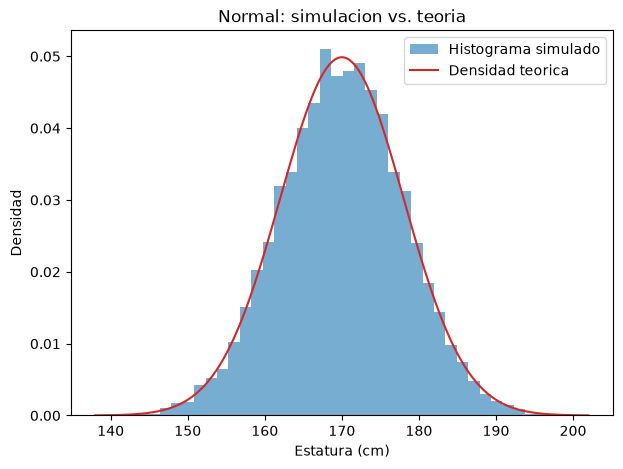

In [28]:
muestra = dist_normal.rvs(size=10_000, random_state=rng)

plt.figure()
plt.hist(muestra, bins=40, density=True, alpha=0.6, color="tab:blue", label="Histograma simulado")
plt.plot(x_vals, dist_normal.pdf(x_vals), color="tab:red", label="Densidad teorica")
plt.xlabel("Estatura (cm)")
plt.ylabel("Densidad")
plt.title("Normal: simulacion vs. teoria")
plt.legend()
plt.show()

## B.3 Exponencial

Modela el tiempo entre eventos de un proceso Poisson con tasa $\lambda$ (eventos por unidad de tiempo).

$$f(x) = \lambda e^{-\lambda x}, \; x \ge 0 \qquad F(x) = 1 - e^{-\lambda x} \qquad\qquad E[X] = \frac{1}{\lambda} \qquad\qquad \text{Var}(X) = \frac{1}{\lambda^2}$$

Ejemplo: el tiempo entre llegadas de clientes a una tienda, con tasa $\lambda = 3$ clientes por hora, $X \sim \text{Exponencial}(\lambda = 3)$.

In [29]:
lam = 3
dist_exponencial = stats.expon(scale=1 / lam)  # scipy parametriza con scale = 1/lambda

print("Esperanza teorica E[X] =", round(dist_exponencial.mean(), 4), " (formula: 1/lambda =", round(1 / lam, 4), ")")
print("Varianza teorica Var(X) =", round(dist_exponencial.var(), 4), " (formula: 1/lambda^2 =", round(1 / lam**2, 4), ")")
print("P(X <= 0.5) (menos de media hora entre clientes) =", round(dist_exponencial.cdf(0.5), 4))

Esperanza teorica E[X] = 0.3333  (formula: 1/lambda = 0.3333 )
Varianza teorica Var(X) = 0.1111  (formula: 1/lambda^2 = 0.1111 )
P(X <= 0.5) (menos de media hora entre clientes) = 0.7769


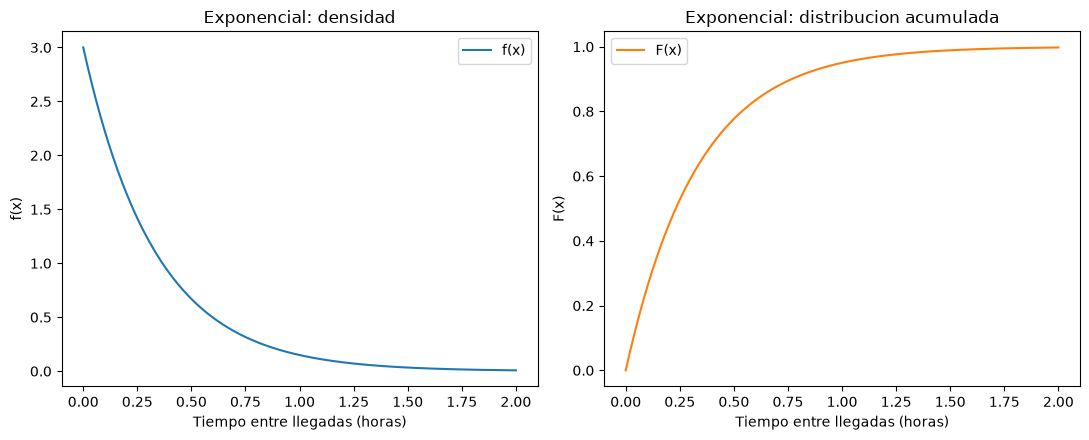

In [30]:
x_vals = np.linspace(0, 2, 400)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(x_vals, dist_exponencial.pdf(x_vals), label="f(x)")
axes[0].set_title("Exponencial: densidad")
axes[0].set_xlabel("Tiempo entre llegadas (horas)")
axes[0].set_ylabel("f(x)")
axes[0].legend()

axes[1].plot(x_vals, dist_exponencial.cdf(x_vals), color="tab:orange", label="F(x)")
axes[1].set_title("Exponencial: distribucion acumulada")
axes[1].set_xlabel("Tiempo entre llegadas (horas)")
axes[1].set_ylabel("F(x)")
axes[1].legend()
plt.tight_layout()
plt.show()

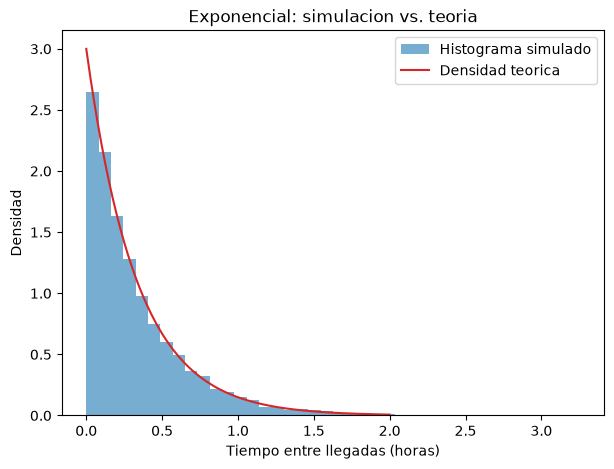

In [31]:
muestra = dist_exponencial.rvs(size=10_000, random_state=rng)

plt.figure()
plt.hist(muestra, bins=40, density=True, alpha=0.6, color="tab:blue", label="Histograma simulado")
plt.plot(x_vals, dist_exponencial.pdf(x_vals), color="tab:red", label="Densidad teorica")
plt.xlabel("Tiempo entre llegadas (horas)")
plt.ylabel("Densidad")
plt.title("Exponencial: simulacion vs. teoria")
plt.legend()
plt.show()

## B.4 Gamma

Generaliza a la exponencial: modela el tiempo hasta que ocurren $k$ eventos de un proceso Poisson con tasa $\lambda$ (equivalente a la suma de $k$ variables exponenciales independientes con tasa $\lambda$).

$$f(x) = \frac{\lambda^k x^{k-1} e^{-\lambda x}}{\Gamma(k)}, \; x \ge 0 \qquad\qquad E[X] = \frac{k}{\lambda} \qquad\qquad \text{Var}(X) = \frac{k}{\lambda^2}$$

Ejemplo: tiempo hasta que lleguen $k = 4$ clientes a la misma tienda de la sección anterior ($\lambda = 3$ clientes por hora).

In [32]:
k, lam = 4, 3
dist_gamma = stats.gamma(a=k, scale=1 / lam)  # scipy usa 'a' como el parametro de forma k

print("Esperanza teorica E[X] =", round(dist_gamma.mean(), 4), " (formula: k/lambda =", round(k / lam, 4), ")")
print("Varianza teorica Var(X) =", round(dist_gamma.var(), 4), " (formula: k/lambda^2 =", round(k / lam**2, 4), ")")
print("P(X <= 1) (menos de 1 hora para 4 clientes) =", round(dist_gamma.cdf(1), 4))

Esperanza teorica E[X] = 1.3333  (formula: k/lambda = 1.3333 )
Varianza teorica Var(X) = 0.4444  (formula: k/lambda^2 = 0.4444 )
P(X <= 1) (menos de 1 hora para 4 clientes) = 0.3528


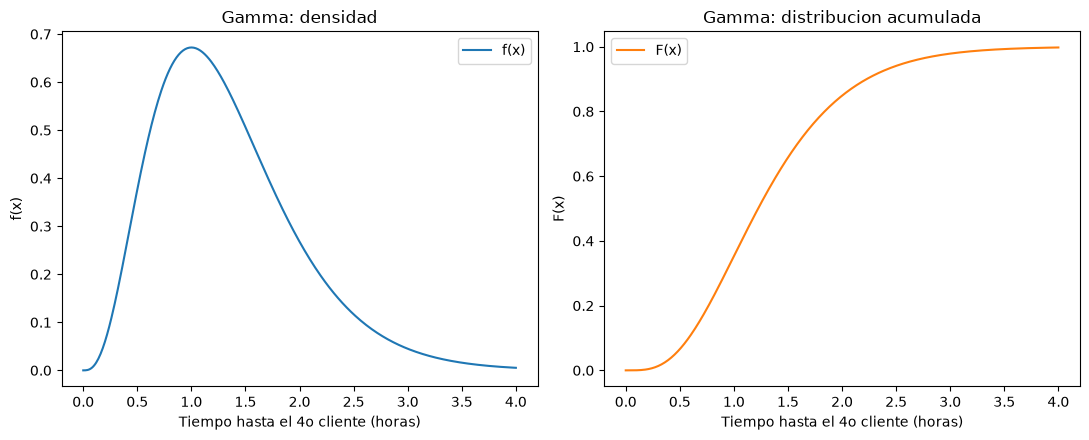

In [33]:
x_vals = np.linspace(0, 4, 400)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(x_vals, dist_gamma.pdf(x_vals), label="f(x)")
axes[0].set_title("Gamma: densidad")
axes[0].set_xlabel("Tiempo hasta el 4o cliente (horas)")
axes[0].set_ylabel("f(x)")
axes[0].legend()

axes[1].plot(x_vals, dist_gamma.cdf(x_vals), color="tab:orange", label="F(x)")
axes[1].set_title("Gamma: distribucion acumulada")
axes[1].set_xlabel("Tiempo hasta el 4o cliente (horas)")
axes[1].set_ylabel("F(x)")
axes[1].legend()
plt.tight_layout()
plt.show()

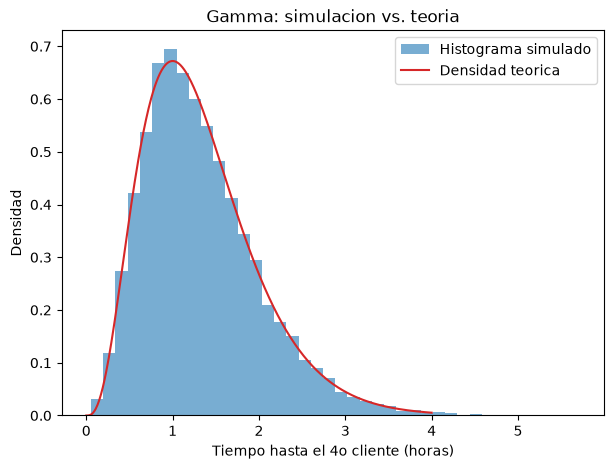

In [34]:
muestra = dist_gamma.rvs(size=10_000, random_state=rng)

plt.figure()
plt.hist(muestra, bins=40, density=True, alpha=0.6, color="tab:blue", label="Histograma simulado")
plt.plot(x_vals, dist_gamma.pdf(x_vals), color="tab:red", label="Densidad teorica")
plt.xlabel("Tiempo hasta el 4o cliente (horas)")
plt.ylabel("Densidad")
plt.title("Gamma: simulacion vs. teoria")
plt.legend()
plt.show()

---
# C. Simulación de variables aleatorias: método de la transformada inversa

Si $U \sim \text{Uniforme}(0,1)$ y $F$ es la función de distribución (continua y estrictamente creciente) de una variable $X$, entonces

$$X = F^{-1}(U)$$

tiene exactamente la distribución $F$. Este resultado, conocido como **método de la transformada inversa**, permite simular cualquier variable aleatoria de la que se conozca $F^{-1}$ en forma cerrada a partir de números uniformes.

Para la exponencial de tasa $\lambda$, $F(x) = 1 - e^{-\lambda x}$, por lo que

$$F^{-1}(u) = -\frac{\ln(1-u)}{\lambda}.$$

Se implementa manualmente esta fórmula (sin usar `dist.rvs`) y se compara contra la teoría.

In [35]:
lam = 3
u = rng.uniform(0, 1, size=10_000)
muestra_transformada_inversa = -np.log(1 - u) / lam  # F^-1(u) para la exponencial

media_teorica = 1 / lam
var_teorica = 1 / lam**2
media_muestral = muestra_transformada_inversa.mean()
var_muestral = muestra_transformada_inversa.var()

print("Media teorica:", round(media_teorica, 4), " | Media muestral (transformada inversa):", round(media_muestral, 4))
print("Varianza teorica:", round(var_teorica, 4), " | Varianza muestral (transformada inversa):", round(var_muestral, 4))

Media teorica: 0.3333  | Media muestral (transformada inversa): 0.3269
Varianza teorica: 0.1111  | Varianza muestral (transformada inversa): 0.1036


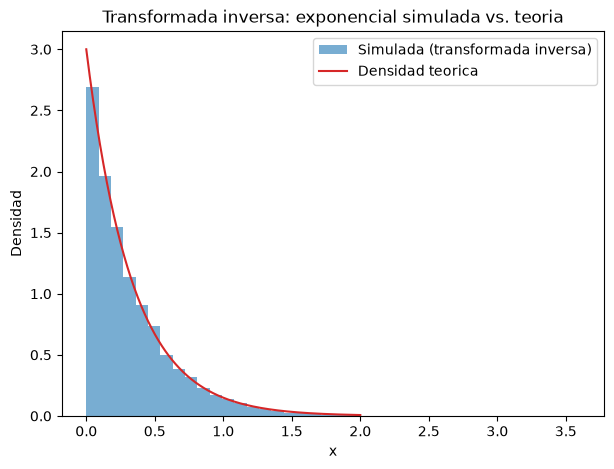

In [36]:
x_vals = np.linspace(0, 2, 400)
plt.figure()
plt.hist(muestra_transformada_inversa, bins=40, density=True, alpha=0.6, color="tab:blue",
         label="Simulada (transformada inversa)")
plt.plot(x_vals, stats.expon(scale=1 / lam).pdf(x_vals), color="tab:red", label="Densidad teorica")
plt.xlabel("x")
plt.ylabel("Densidad")
plt.title("Transformada inversa: exponencial simulada vs. teoria")
plt.legend()
plt.show()

**Comparación teoría vs. simulación (resumen):** en las secciones B.1-B.4 y en la transformada inversa anterior, cada histograma simulado se superpone casi exactamente con la densidad teórica, y las medias y varianzas muestrales coinciden con las teóricas hasta el segundo o tercer decimal. Esto confirma que tanto el generador de números aleatorios de `scipy.stats` como la implementación manual por transformada inversa reproducen correctamente la distribución buscada; las pequeñas diferencias remanentes se deben únicamente al error de muestreo, que disminuye al aumentar el tamaño de la simulación (ver Ley de los Grandes Números, sección E).

---
# D. Función generadora de momentos (FGM)

La función generadora de momentos de $X$ se define como

$$M_X(t) = E\left[e^{tX}\right],$$

cuando esta esperanza existe en un intervalo alrededor de $t=0$. Sus propiedades principales:

- $M_X(0) = 1$.
- Los momentos de $X$ se obtienen derivando y evaluando en $t=0$: $E[X^k] = M_X^{(k)}(0)$. En particular $E[X] = M_X'(0)$ y $E[X^2] = M_X''(0)$.
- Si dos variables tienen la misma FGM en un intervalo alrededor de 0, tienen la misma distribución (unicidad).

**Ejemplo (exponencial):** para $X \sim \text{Exponencial}(\lambda)$,

$$M_X(t) = E[e^{tX}] = \int_0^{\infty} e^{tx} \lambda e^{-\lambda x}\,dx = \frac{\lambda}{\lambda - t}, \quad t < \lambda.$$

Derivando, $M_X'(t) = \dfrac{\lambda}{(\lambda-t)^2}$ y $M_X'(0) = \dfrac{1}{\lambda} = E[X]$, que coincide con el resultado ya conocido. Se verifica numéricamente derivando $M_X(t)$ por diferencias finitas.

In [37]:
lam = 3

def fgm_exponencial(t, lam=lam):
    return lam / (lam - t)

def derivada_numerica(func, t0, h=1e-5, orden=1):
    """Aproxima la derivada de 'func' en t0 usando diferencias finitas centradas."""
    if orden == 1:
        return (func(t0 + h) - func(t0 - h)) / (2 * h)
    if orden == 2:
        return (func(t0 + h) - 2 * func(t0) + func(t0 - h)) / h**2
    raise ValueError("Solo se implementan las derivadas de orden 1 y 2")

E_X_fgm = derivada_numerica(fgm_exponencial, 0, orden=1)
E_X2_fgm = derivada_numerica(fgm_exponencial, 0, orden=2)

dist_exponencial = stats.expon(scale=1 / lam)
print("M_X'(0)  (derivada numerica) =", round(E_X_fgm, 4), " | E[X] teorica (scipy) =", round(dist_exponencial.mean(), 4))
print("M_X''(0) (derivada numerica) =", round(E_X2_fgm, 4), " | E[X^2] teorica =",
      round(dist_exponencial.var() + dist_exponencial.mean()**2, 4))

M_X'(0)  (derivada numerica) = 0.3333  | E[X] teorica (scipy) = 0.3333
M_X''(0) (derivada numerica) = 0.2222  | E[X^2] teorica = 0.2222


**Interpretación:** la primera derivada de la FGM en 0, obtenida numéricamente, coincide con $E[X]$ y la segunda derivada coincide con $E[X^2] = \text{Var}(X) + (E[X])^2$. Esto confirma en un caso concreto la propiedad general de que la FGM "genera" los momentos de la distribución.

---
# E. Función característica (FC)

La función característica de $X$ se define como

$$\varphi_X(t) = E\left[e^{itX}\right] = E[\cos(tX)] + i\,E[\sin(tX)],$$

donde $i = \sqrt{-1}$. A diferencia de la FGM, **siempre existe** (porque $|e^{itX}| = 1$), y también caracteriza de forma única a la distribución.

**Ejemplo (Normal):** para $X \sim N(\mu, \sigma^2)$, la forma cerrada es

$$\varphi_X(t) = e^{i\mu t - \tfrac{1}{2}\sigma^2 t^2}.$$

Se verifica numéricamente promediando $e^{itX}$ sobre una muestra simulada y comparando con la fórmula cerrada.

In [38]:
mu, sigma = 170, 8
dist_normal = stats.norm(loc=mu, scale=sigma)
muestra = dist_normal.rvs(size=200_000, random_state=rng)

t_vals = np.linspace(-0.5, 0.5, 100)
fc_teorica = np.exp(1j * mu * t_vals - 0.5 * sigma**2 * t_vals**2)
fc_empirica = np.array([np.mean(np.exp(1j * t * muestra)) for t in t_vals])

print("phi_X(0.1) teorica :", np.round(fc_teorica[np.argmin(np.abs(t_vals - 0.1))], 4))
print("phi_X(0.1) empirica:", np.round(fc_empirica[np.argmin(np.abs(t_vals - 0.1))], 4))

phi_X(0.1) teorica : (-0.6125-0.4237j)
phi_X(0.1) empirica: (-0.6117-0.4223j)


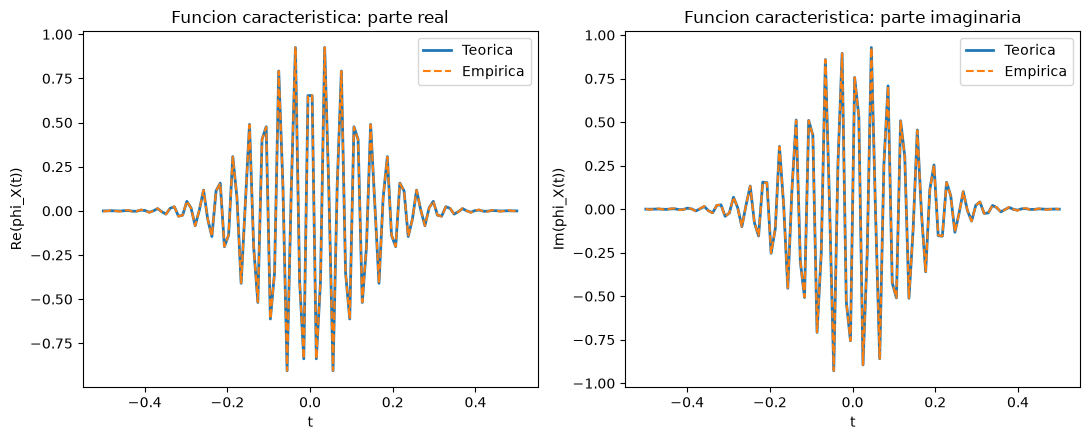

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(t_vals, fc_teorica.real, label="Teorica", linewidth=2)
axes[0].plot(t_vals, fc_empirica.real, "--", label="Empirica")
axes[0].set_title("Funcion caracteristica: parte real")
axes[0].set_xlabel("t")
axes[0].set_ylabel("Re(phi_X(t))")
axes[0].legend()

axes[1].plot(t_vals, fc_teorica.imag, label="Teorica", linewidth=2)
axes[1].plot(t_vals, fc_empirica.imag, "--", label="Empirica")
axes[1].set_title("Funcion caracteristica: parte imaginaria")
axes[1].set_xlabel("t")
axes[1].set_ylabel("Im(phi_X(t))")
axes[1].legend()
plt.tight_layout()
plt.show()

**Interpretación:** la curva empírica (promedio muestral de $e^{itX}$) sigue de cerca la curva teórica tanto en parte real como imaginaria, lo que confirma la fórmula cerrada de la función característica de la Normal. Nótese que, a diferencia de la FGM, la FC de la Normal está definida para todo $t \in \mathbb{R}$.

---
# F. Ley de los Grandes Números (LGN)

La Ley de los Grandes Números establece que, si $X_1, X_2, \dots$ son variables aleatorias independientes e idénticamente distribuidas con esperanza finita $\mu = E[X_i]$, el promedio muestral

$$\bar{X}_n = \frac{1}{n}\sum_{i=1}^n X_i$$

converge a $\mu$ conforme $n \to \infty$. En otras palabras, el promedio de muchas observaciones se estabiliza alrededor de la esperanza teórica. Se ilustra con una distribución exponencial de tasa $\lambda = 3$ (esperanza teórica $1/\lambda$).

In [40]:
lam = 3
n_max = 20_000
muestra = stats.expon(scale=1 / lam).rvs(size=n_max, random_state=rng)

tamanos = np.arange(1, n_max + 1)
promedio_acumulado = np.cumsum(muestra) / tamanos

print("Esperanza teorica E[X] =", round(1 / lam, 4))
print("Promedio muestral con n=10:   ", round(promedio_acumulado[9], 4))
print("Promedio muestral con n=1000: ", round(promedio_acumulado[999], 4))
print(f"Promedio muestral con n={n_max}:", round(promedio_acumulado[-1], 4))

Esperanza teorica E[X] = 0.3333
Promedio muestral con n=10:    0.2315
Promedio muestral con n=1000:  0.3225
Promedio muestral con n=20000: 0.3365


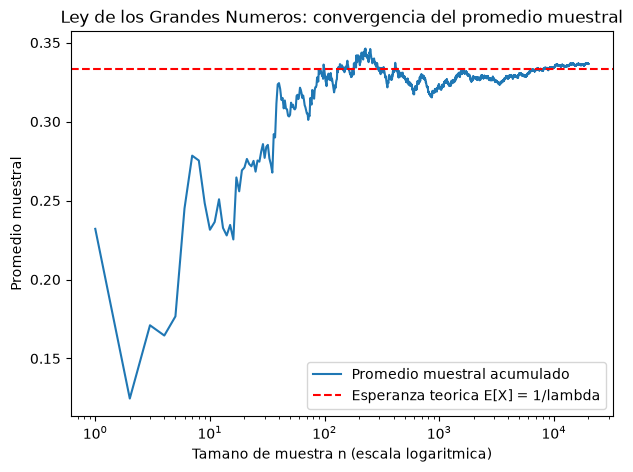

In [41]:
plt.figure()
plt.plot(tamanos, promedio_acumulado, label="Promedio muestral acumulado")
plt.axhline(1 / lam, color="red", linestyle="--", label="Esperanza teorica E[X] = 1/lambda")
plt.xscale("log")
plt.xlabel("Tamano de muestra n (escala logaritmica)")
plt.ylabel("Promedio muestral")
plt.title("Ley de los Grandes Numeros: convergencia del promedio muestral")
plt.legend()
plt.show()

**Interpretación:** con pocas observaciones el promedio muestral fluctúa bastante, pero al aumentar $n$ la curva se aproxima cada vez más a la línea roja (la esperanza teórica), tal como predice la Ley de los Grandes Números.

---
# G. Teorema Central del Límite (TCL)

El Teorema Central del Límite establece que, si $X_1, \dots, X_n$ son independientes e idénticamente distribuidas con media $\mu$ y varianza $\sigma^2$ finita, entonces la distribución del promedio muestral estandarizado se aproxima a una Normal estándar conforme $n$ crece:

$$\frac{\bar{X}_n - \mu}{\sigma/\sqrt{n}} \xrightarrow{d} N(0, 1).$$

Lo notable es que esto ocurre **sin importar la forma de la distribución original** de $X_i$, siempre que tenga varianza finita. Se ilustra partiendo de una distribución exponencial (muy asimétrica) y observando cómo la distribución de $\bar{X}_n$ se va pareciendo a una Normal al aumentar $n$.

In [42]:
lam = 3
mu, sigma = 1 / lam, 1 / lam  # media y desviacion estandar de la exponencial(lambda=3)
tamanos_muestra = [1, 5, 30, 100]
n_repeticiones = 10_000

medias_por_n = {}
for n in tamanos_muestra:
    datos = stats.expon(scale=1 / lam).rvs(size=(n_repeticiones, n), random_state=rng)
    medias_por_n[n] = datos.mean(axis=1)
    print(f"n={n:>3}: media de las medias muestrales = {medias_por_n[n].mean():.4f}, "
          f"desviacion estandar = {medias_por_n[n].std():.4f} "
          f"(teorica: {sigma / np.sqrt(n):.4f})")

n=  1: media de las medias muestrales = 0.3383, desviacion estandar = 0.3376 (teorica: 0.3333)
n=  5: media de las medias muestrales = 0.3328, desviacion estandar = 0.1488 (teorica: 0.1491)
n= 30: media de las medias muestrales = 0.3331, desviacion estandar = 0.0612 (teorica: 0.0609)
n=100: media de las medias muestrales = 0.3335, desviacion estandar = 0.0337 (teorica: 0.0333)


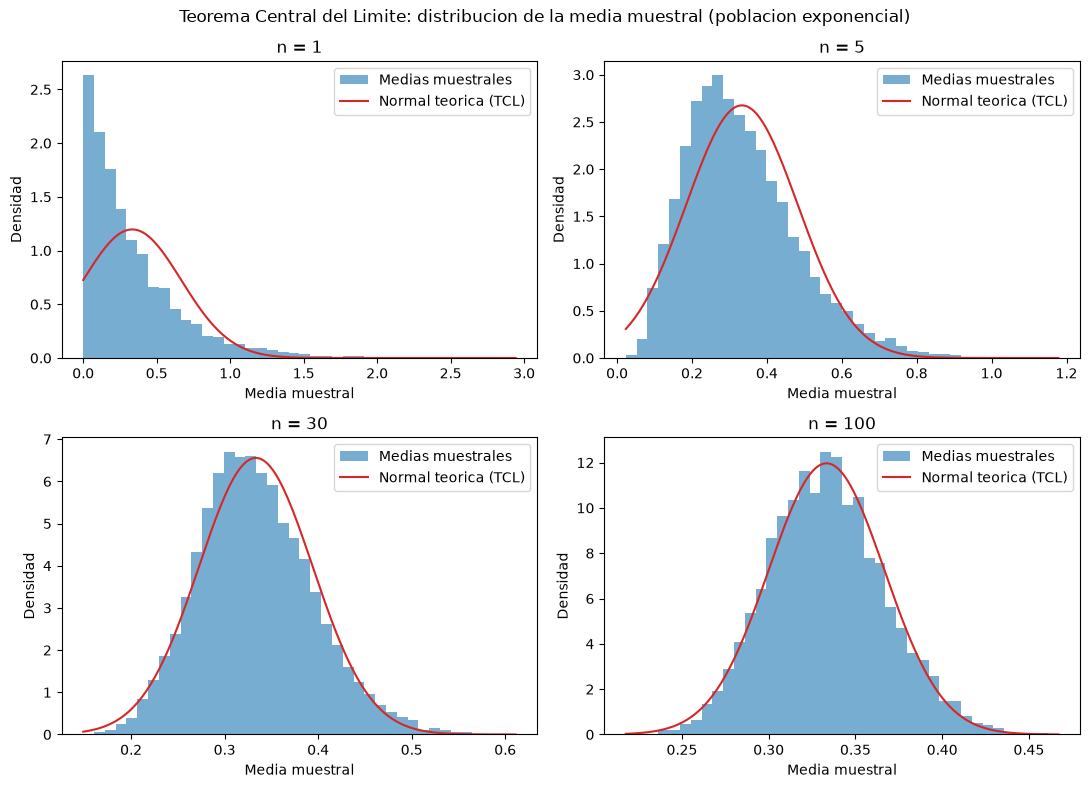

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, n in zip(axes.ravel(), tamanos_muestra):
    ax.hist(medias_por_n[n], bins=40, density=True, alpha=0.6, color="tab:blue", label="Medias muestrales")
    x_vals = np.linspace(medias_por_n[n].min(), medias_por_n[n].max(), 200)
    ax.plot(x_vals, stats.norm(loc=mu, scale=sigma / np.sqrt(n)).pdf(x_vals), color="tab:red",
            label="Normal teorica (TCL)")
    ax.set_title(f"n = {n}")
    ax.set_xlabel("Media muestral")
    ax.set_ylabel("Densidad")
    ax.legend()
plt.suptitle("Teorema Central del Limite: distribucion de la media muestral (poblacion exponencial)")
plt.tight_layout()
plt.show()

**Interpretación:** con $n=1$ el histograma es idéntico a la exponencial original (muy asimétrica). Conforme $n$ crece (5, 30, 100), el histograma de las medias muestrales se vuelve cada vez más simétrico y se ajusta mejor a la curva Normal teórica con media $\mu$ y desviación estándar $\sigma/\sqrt{n}$, ilustrando el TCL en acción.

---
## Conclusión del Notebook 2

Las distribuciones discretas y continuas presentadas comparten una misma estructura: una función de probabilidad (o densidad) que describe el comportamiento aleatorio de la variable, y momentos (esperanza, varianza) que resumen sus características principales. La simulación en Python, ya sea usando `scipy.stats` o el método de la transformada inversa, permite verificar empíricamente que la teoría describe correctamente el comportamiento a largo plazo de estas variables.

La FGM y la FC son herramientas más abstractas que "codifican" todos los momentos de una distribución en una sola función, y permiten demostrar propiedades de forma más sencilla que trabajando directamente con la densidad. La Ley de los Grandes Números explica por qué el promedio muestral es un buen estimador de la esperanza, mientras que el Teorema Central del Límite explica por qué, sin importar la distribución original, las medias muestrales tienden a una Normal: este resultado es la base de gran parte de la inferencia estadística que se desarrolla en el Notebook 3.

---
## Bibliografía

- Rincón, L. (2014). *Curso elemental de probabilidad y estadística*. Facultad de Ciencias, UNAM.
- Ross, S. M. (2010). *A First Course in Probability* (8a ed.). Pearson.
- Mood, A. M., Graybill, F. A., & Boes, D. C. (1974). *Introduction to the Theory of Statistics* (3a ed.). McGraw-Hill.
- Mendenhall, W., Beaver, R. J., & Beaver, B. M. (2013). *Introduction to Probability and Statistics* (14a ed.). Cengage Learning.